# 5 ~ Robustez a ruido en las features

La idea acá es otra: en vez de agregar features, **ensuciar las que ya tenemos** y ver
qué tan bien aguanta el modelo final (el seed-ensemble de VAEs `recon_prob`, nb 4).

En la práctica, las estaciones/satélites que alimentan el panel (clima, NDVI, ERA5) no son
perfectos — hay error de medición, interpolación espacial, gaps rellenados. Si el detector
es sensible a perturbaciones chicas de esas features, su performance en producción es menos
confiable de lo que sugiere el test limpio. Acá inyectamos **ruido gaussiano creciente**
sobre `X_test` (las features ya están normalizadas por depto, así que el nivel de ruido se
interpreta directamente como una fracción del desvío típico de cada feature) y medimos cómo
se degrada el PR-AUC del ensemble a medida que sube el ruido — para soja y maíz.

In [6]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


## 5.1 ~ Dataset y modelo final (seed-ensemble VAE)
Reusamos la arquitectura ganadora **de cada cultivo** (nb 3/4): `hidden_dims=(128,64)`,
`score_mode="recon_prob"`, pero `latent_dim=16` en soja y `latent_dim=24` en maíz — no
comparten la misma arquitectura óptima, en ensemble de 10 semillas.

In [7]:
panel_z = data.prepare()                              # panel unificado (clima+NDVI+ERA5)
datasets = {
    "soja": data.build_crop_dataset(panel_z, "soja"),
    "maiz": data.build_crop_dataset(panel_z, "maiz"),
}
for nombre, d in datasets.items():
    print(f"{nombre:6s} {len(d.feature_cols):3d} features | train {d.X_train.shape[0]} | "
          f"test {d.X_test.shape[0]} (anómalas: {int(d.y_test.sum())})")

BEST = {
    "soja": dict(hidden_dims=(128, 64), latent_dim=16),
    "maiz": dict(hidden_dims=(128, 64), latent_dim=24),
}  # config ganadora de cada cultivo (nb 3) — no es la misma arquitectura para los dos

def make_ensemble(cultivo, base_seed):
    miembros = [VAEDetector(**BEST[cultivo], score_mode="recon_prob",
                            n_mc_samples=50, max_epochs=300, patience=30,
                            random_state=base_seed + i) for i in range(10)]
    return EnsembleDetector(miembros)

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)
soja    65 features | train 6143 | test 942 (anómalas: 251)
maiz    65 features | train 8082 | test 1160 (anómalas: 344)


## 5.2 ~ Inyección de ruido en test
El ensemble se entrena una sola vez sobre `X_train` limpio (así debe ser: no tiene sentido
entrenar con ruido para esta pregunta, queremos medir robustez en *inferencia*). Después,
para cada nivel de ruido, perturbamos `X_test` con gaussiano `N(0, sigma)` y volvemos a
scorear — el ensemble ya entrenado, sin reentrenar.

In [8]:
NOISE_LEVELS = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0]   # sigma del ruido gaussiano (en unidades de feature normalizada)
BASE_SEEDS   = [42, 52, 62]                       # 3 ensembles de 10 VAEs c/u -> media±std por nivel

def con_ruido(X, sigma, rng):
    if sigma == 0.0:
        return X
    return X + rng.normal(0.0, sigma, size=X.shape)

# --- 1 ensemble entrenado por cultivo (una sola vez, sobre X_train limpio) ---
ensembles = {}
for base in BASE_SEEDS:
    for cultivo, dset in datasets.items():
        ensembles[(cultivo, base)] = make_ensemble(cultivo, base).fit(dset.X_train)
        print(f"entrenado: {cultivo} base_seed={base}")

entrenado: soja base_seed=42
entrenado: maiz base_seed=42
entrenado: soja base_seed=52
entrenado: maiz base_seed=52
entrenado: soja base_seed=62
entrenado: maiz base_seed=62


## 5.3 ~ Resultados (PR-AUC test ± std, por nivel de ruido y cultivo)

In [9]:
filas = []
for cultivo, dset in datasets.items():
    for sigma in NOISE_LEVELS:
        prs = []
        for base in BASE_SEEDS:
            rng = np.random.default_rng(base)          # ruido reproducible por base_seed
            Xte_ruidoso = con_ruido(dset.X_test, sigma, rng)
            scores = ensembles[(cultivo, base)].score_samples(Xte_ruidoso)
            prs.append(lab.metrics(scores, dset.y_test)["pr_auc"])
        filas.append({"cultivo": cultivo, "sigma": sigma,
                       "pr_auc_mean": float(np.mean(prs)), "pr_auc_std": float(np.std(prs))})

tabla_ruido = pd.DataFrame(filas)
tabla_ruido.pivot(index="sigma", columns="cultivo", values="pr_auc_mean")

cultivo,maiz,soja
sigma,,
0.00,0.541235,0.629044
0.10,0.538646,0.629835
0.25,0.530788,0.624627
0.50,0.513387,0.601035
1.00,0.475345,0.548547
2.00,0.403257,0.444135


## 5.4 ~ Curva de degradación
PR-AUC vs. nivel de ruido, por cultivo — para ver a partir de qué sigma el ensemble empieza
a perder capacidad de detección de forma apreciable.

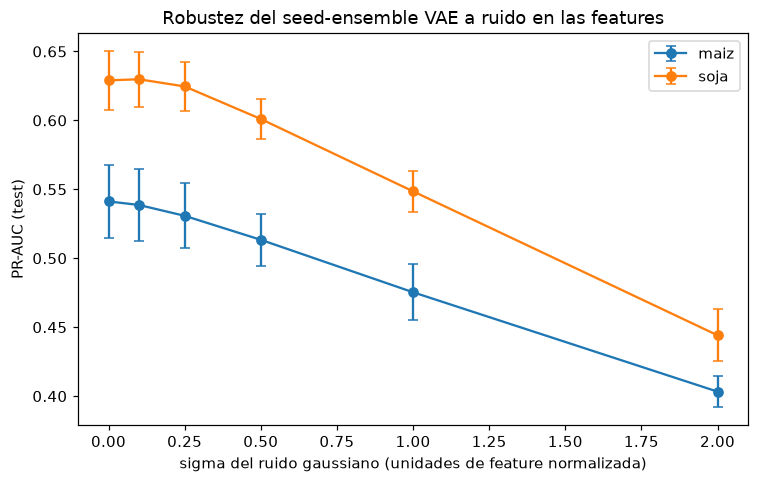

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for cultivo, g in tabla_ruido.groupby("cultivo"):
    ax.errorbar(g["sigma"], g["pr_auc_mean"], yerr=g["pr_auc_std"], marker="o", capsize=3, label=cultivo)
ax.set_xlabel("sigma del ruido gaussiano (unidades de feature normalizada)")
ax.set_ylabel("PR-AUC (test)")
ax.set_title("Robustez del seed-ensemble VAE a ruido en las features")
ax.legend()
plt.tight_layout()
plt.show()